In [ ]:
"""
Notebook: model_base_v1.ipynb
Objetivo: Entrenamiento de modelos base de ML para detección de diabetes
basado en el dataset BRFSS2015 del CDC.
Autor: Jesús Rodríguez
Fecha: 12/11/2025
"""

'\nNotebook: model_base_v1.ipynb\nObjetivo: Entrenamiento de modelos base de ML para detección de diabetes\nbasado en el dataset BRFSS2015 del CDC.\nAutor: Jesús Rodríguez\nFecha: 12/11/2025\n'

## 1. Configuración inicial


In [ ]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, FunctionTransformer
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    precision_recall_curve, auc, confusion_matrix, RocCurveDisplay
)

# Interpretabilidad
from IPython.display import display

# Google Drive
from google.colab import drive

In [ ]:
# Montaje de Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Definición de ruta
DATA_PATH = '/content/drive/MyDrive/TFM/data/cleaned_dataset.csv'

# Carga del dataset
df = pd.read_csv(DATA_PATH, encoding='Latin-1')

## 2. Exploración inicial del dataset

In [ ]:
# Dimensiones y tipos
print("Dimensiones del dataset:", df.shape)
print(df.info())

# Distribución inicial de DIABETE3
print("Distribución original del target:")
print(df["DIABETE3"].value_counts(normalize=True))

Dimensiones del dataset: (257709, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257709 entries, 0 to 257708
Data columns (total 23 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   257709 non-null  float64
 1   BPHIGH4   257709 non-null  float64
 2   BPMEDS    257709 non-null  float64
 3   BLOODCHO  257709 non-null  float64
 4   HAVARTH3  257709 non-null  float64
 5   ADDEPEV2  257709 non-null  float64
 6   DIABETE3  257709 non-null  float64
 7   SEX       257709 non-null  float64
 8   QLACTLM2  257709 non-null  float64
 9   USEEQUIP  257709 non-null  float64
 10  BLIND     257709 non-null  float64
 11  DECIDE    257709 non-null  float64
 12  DIFFWALK  257709 non-null  float64
 13  DIFFDRES  257709 non-null  float64
 14  DIFFALON  257709 non-null  float64
 15  SMOKE100  257709 non-null  float64
 16  EXEROFT1  257709 non-null  float64
 17  _RACE     257709 non-null  float64
 18  _AGEG5YR  257709 non-null  float64
 19  _BMI5C

Distribución del target tras normalización:
DIABETE3
0    229318
1     28391
Name: count, dtype: int64


/tmp/ipython-input-1411977993.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


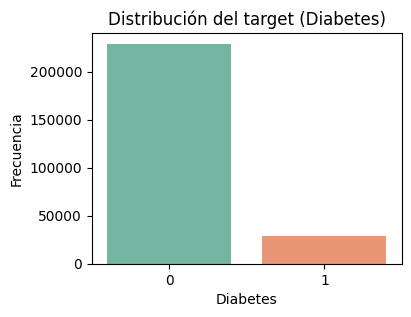

In [ ]:
# Normalización del target: 1 → Diabetes, 0 → No Diabetes
df["DIABETE3"] = df["DIABETE3"].map({1.0: 1, 3.0: 0})

# Comprobación
print("Distribución del target tras normalización:")
print(df["DIABETE3"].value_counts())

# Visualización
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución del target (Diabetes)")
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")
plt.show()

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1. Separación por tipo de variable

In [ ]:
# Definición de categorías de variables
CATEGORICAL_NOMINAL = [
    'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2',
    'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES',
    'DIFFALON', 'SMOKE100', 'ADDEPEV2', '_RACE', 'SEX'
]
CATEGORICAL_ORDINAL = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']
NUMERIC_VARS = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']
TARGET = "DIABETE3"


### 3.2. Variables categóricas nominales

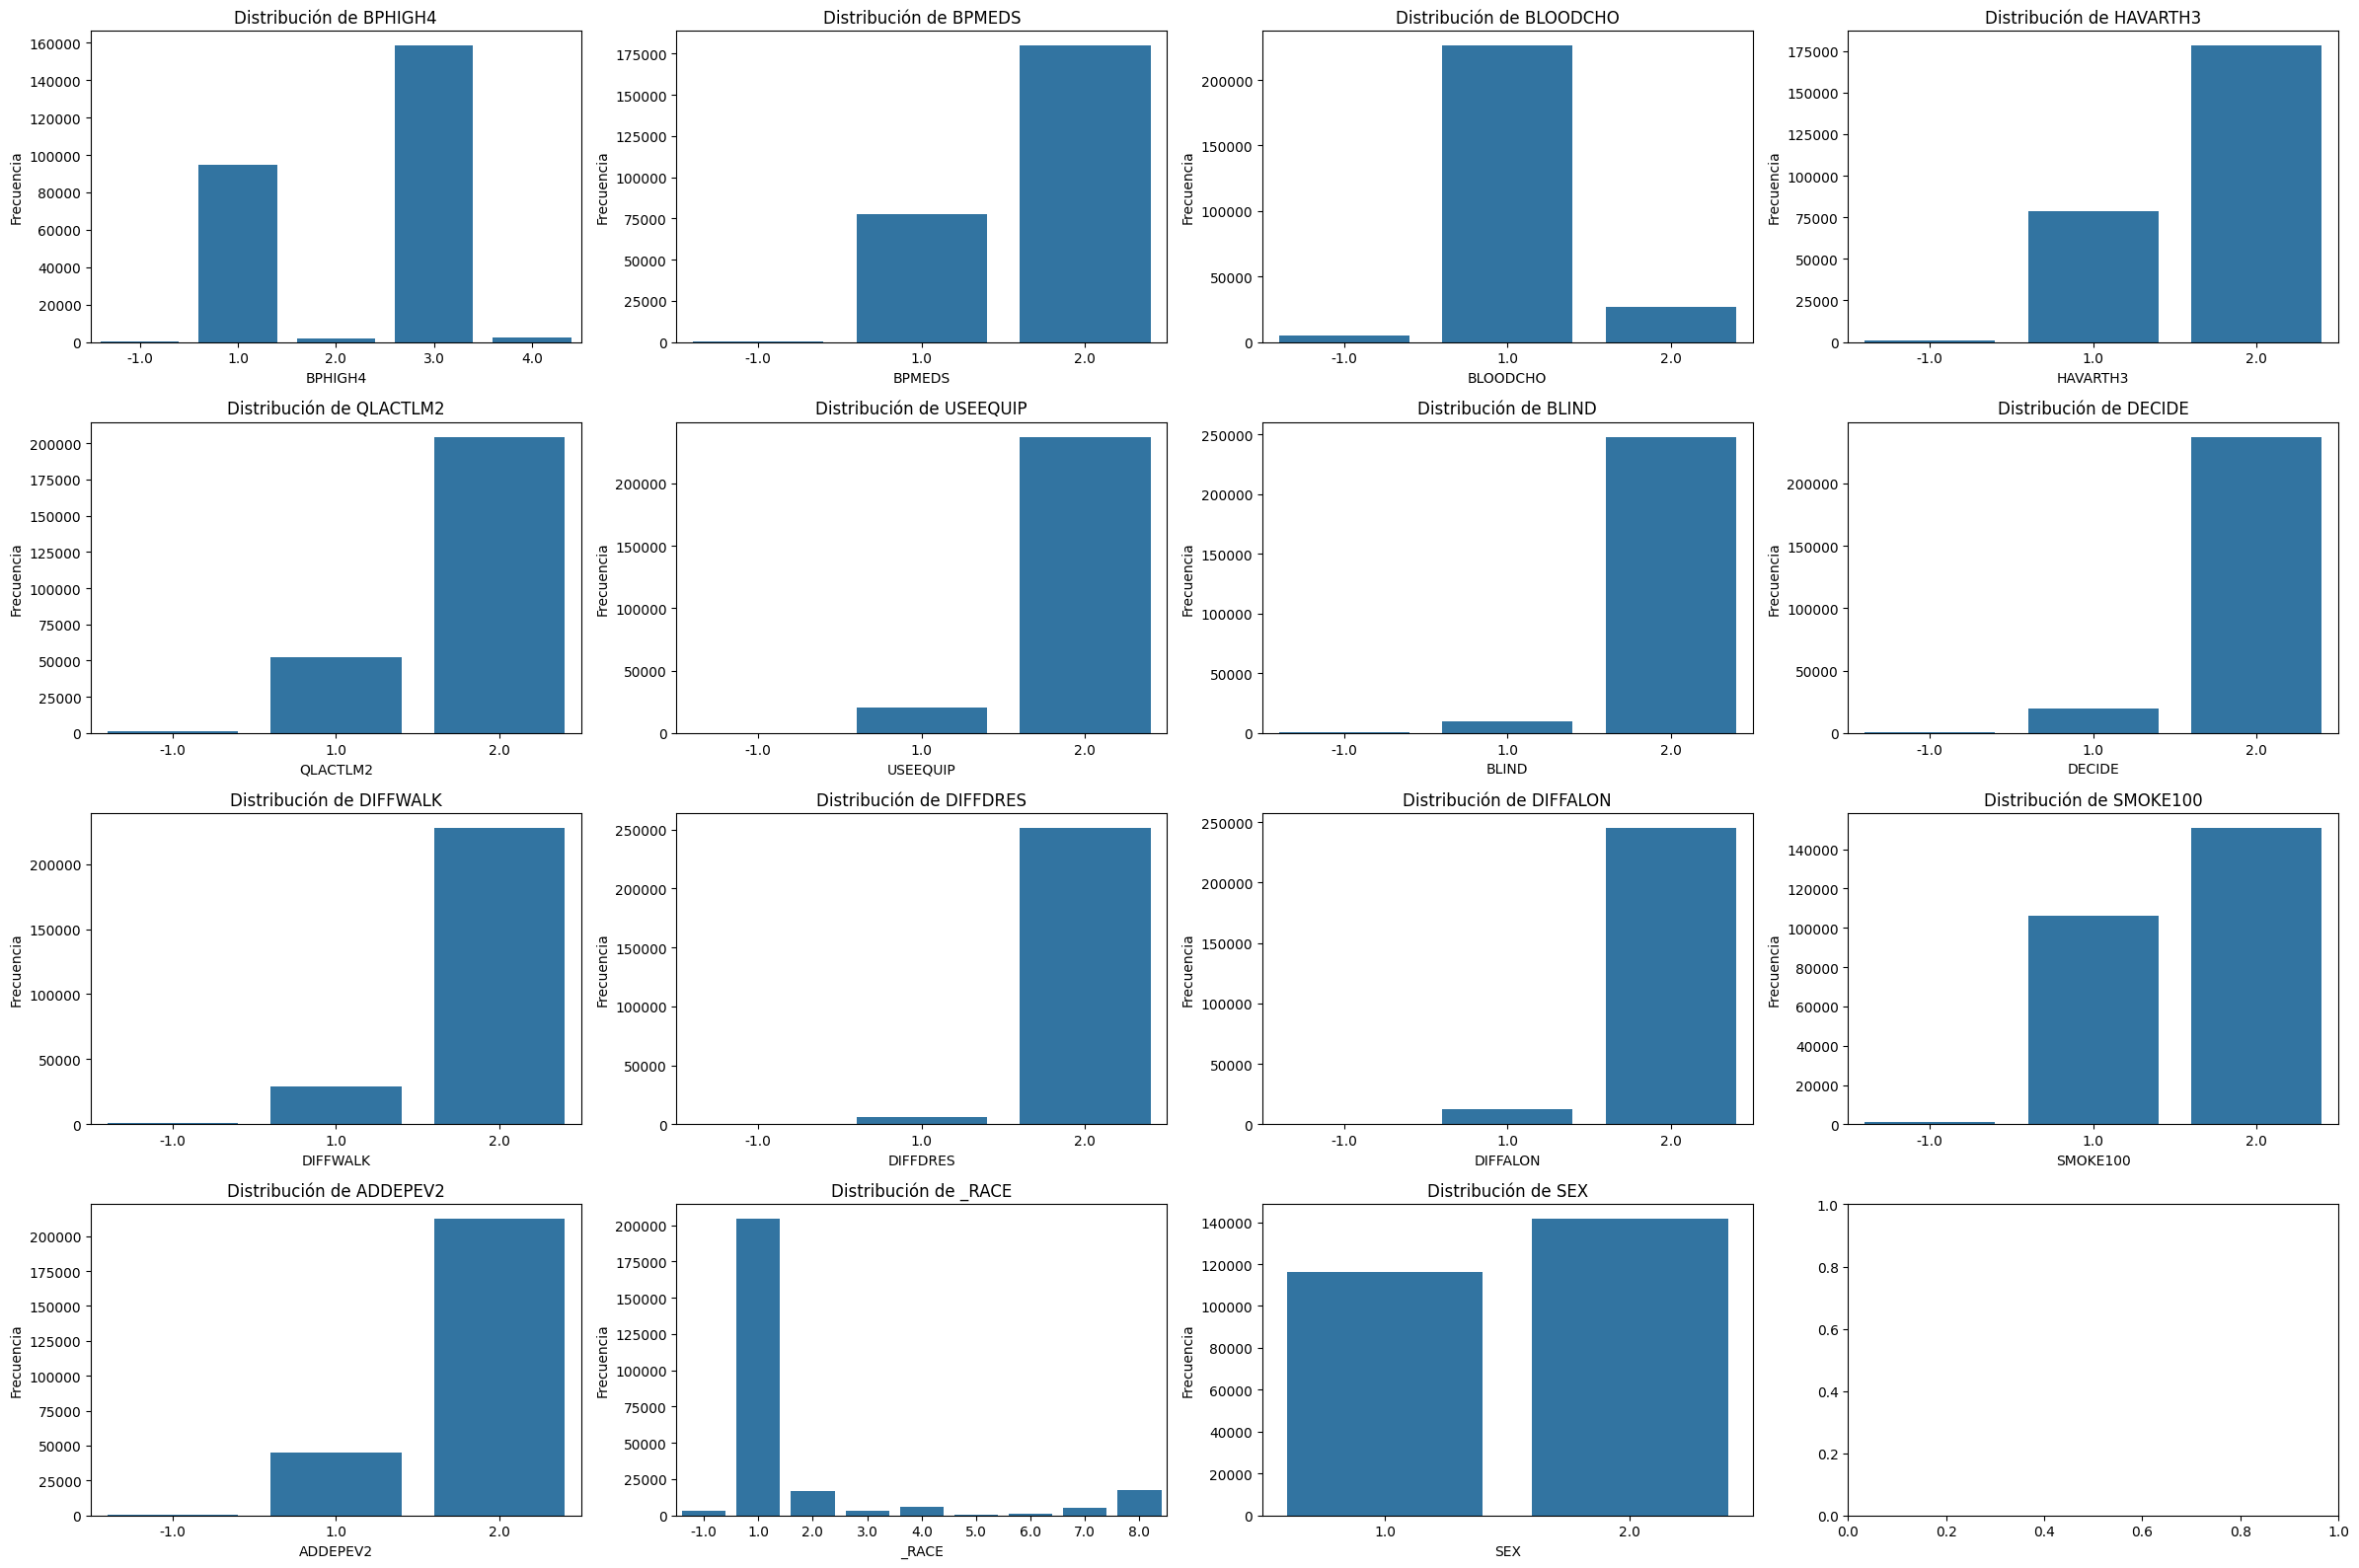

In [ ]:
# Distribución de cada variable nominal
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL_NOMINAL):
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


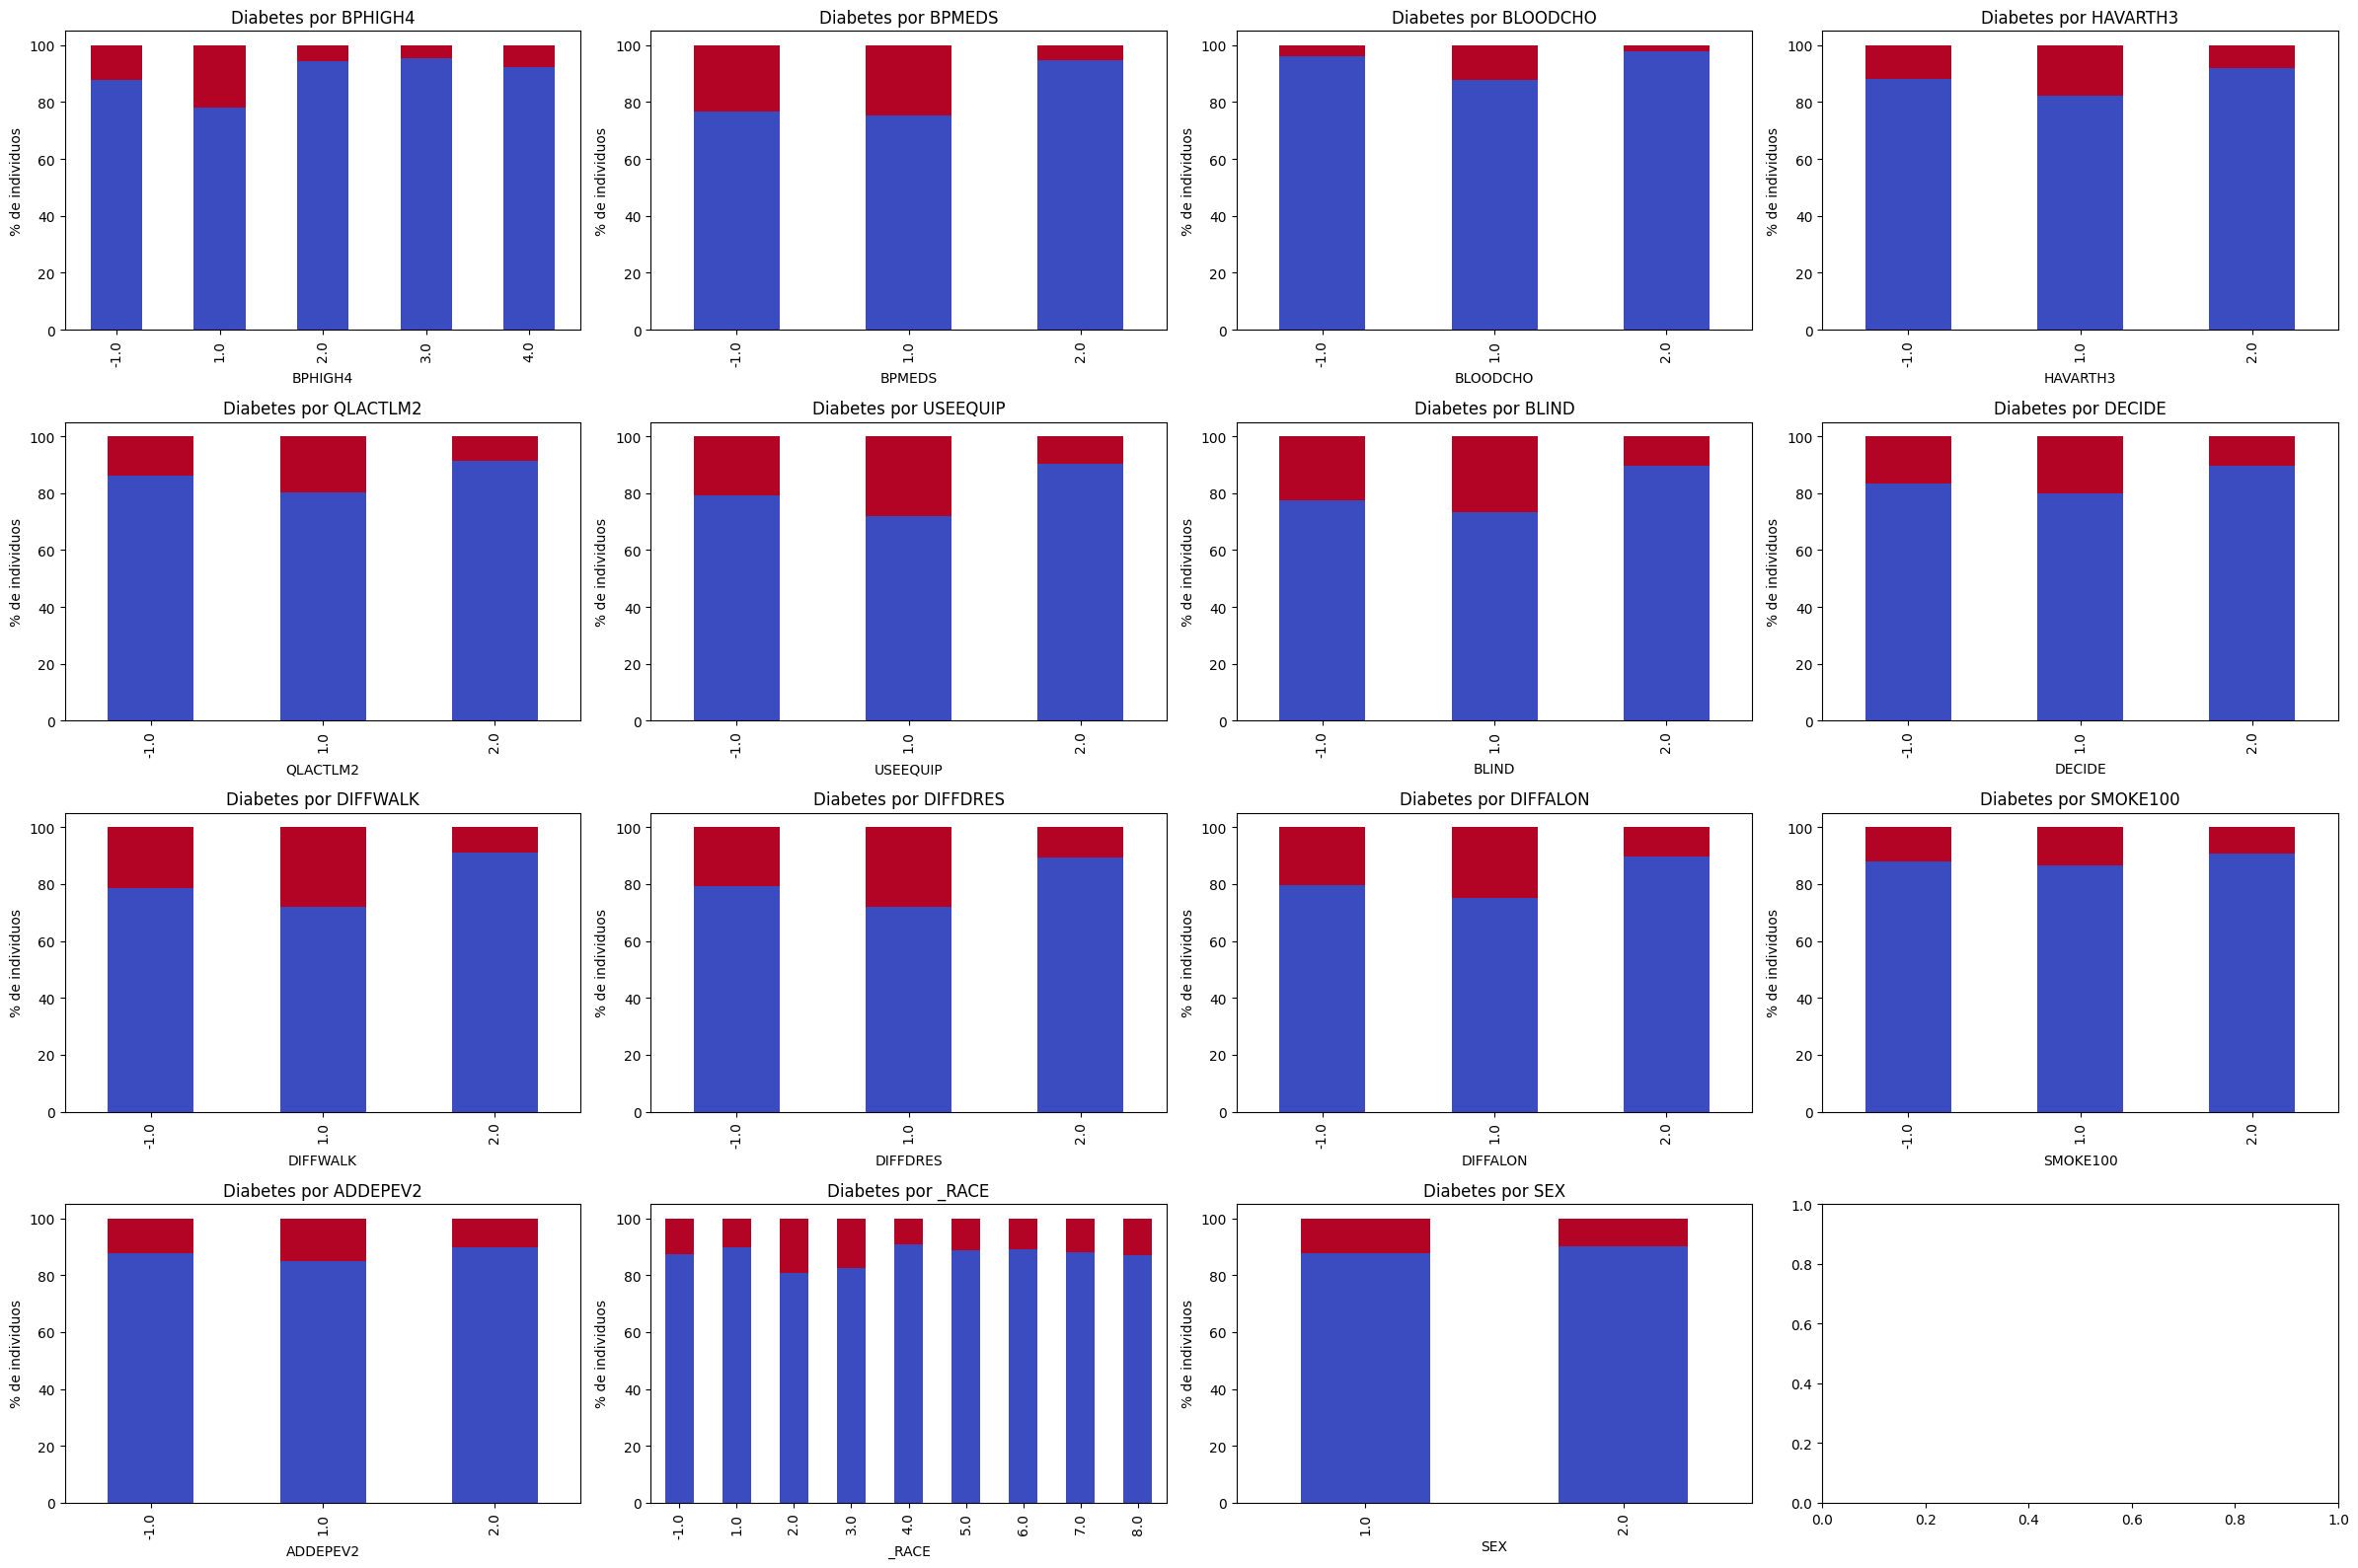

In [ ]:
# Distribución del target según las clases de cada variable nominal
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()
for i, col in enumerate(CATEGORICAL_NOMINAL):
    prop = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    prop.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(f"Diabetes por {col}")
    axes[i].set_ylabel("% de individuos")
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

### 3.3. Variables categóricas ordinales

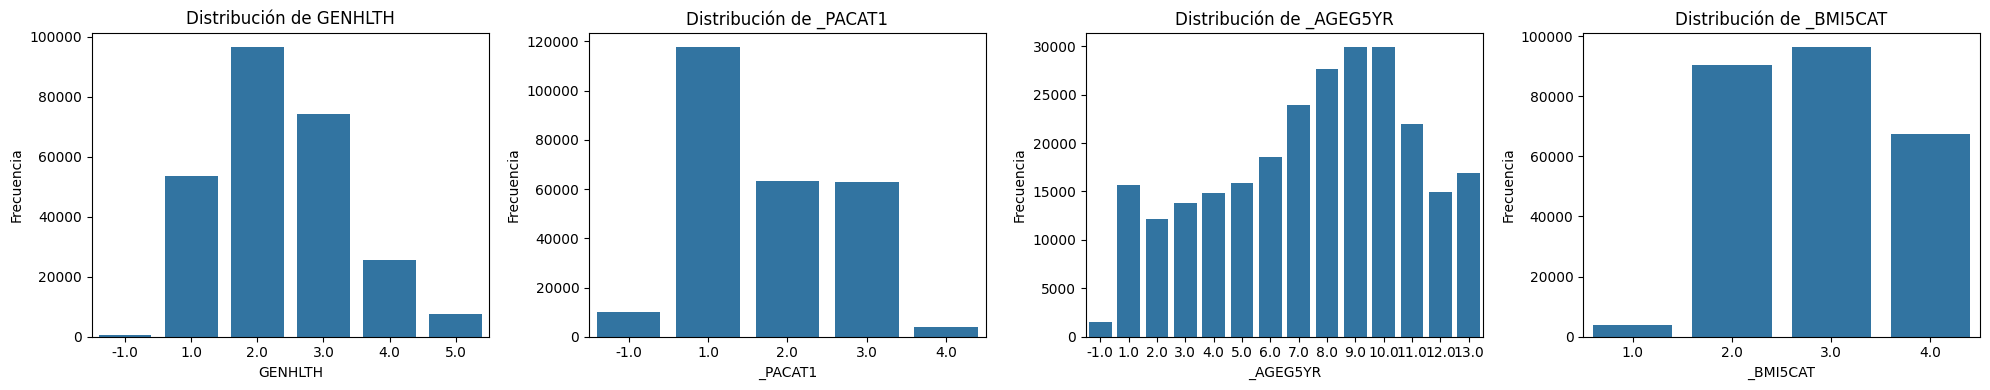

In [ ]:
# Distribución de cada variable ordinal
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(CATEGORICAL_ORDINAL):
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

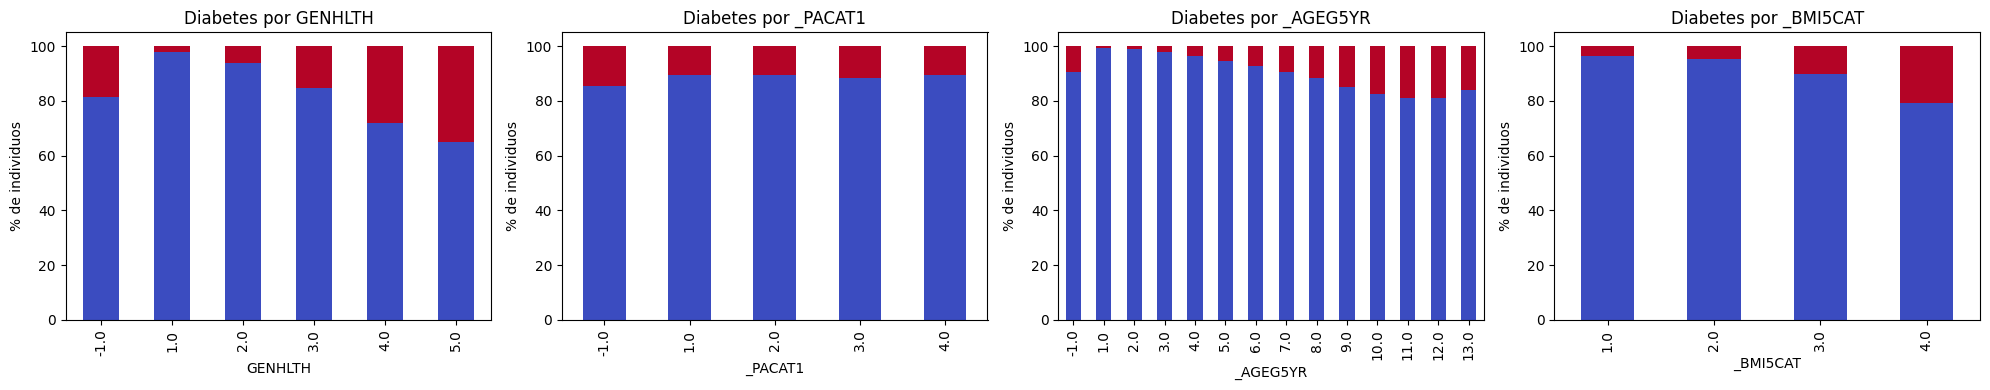

In [ ]:
# Distribución del target según las clases de cada variable ordinal
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(CATEGORICAL_ORDINAL):
    prop = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    prop.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(f"Diabetes por {col}")
    axes[i].set_ylabel("% de individuos")
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

### 3.4. Variables numéricas

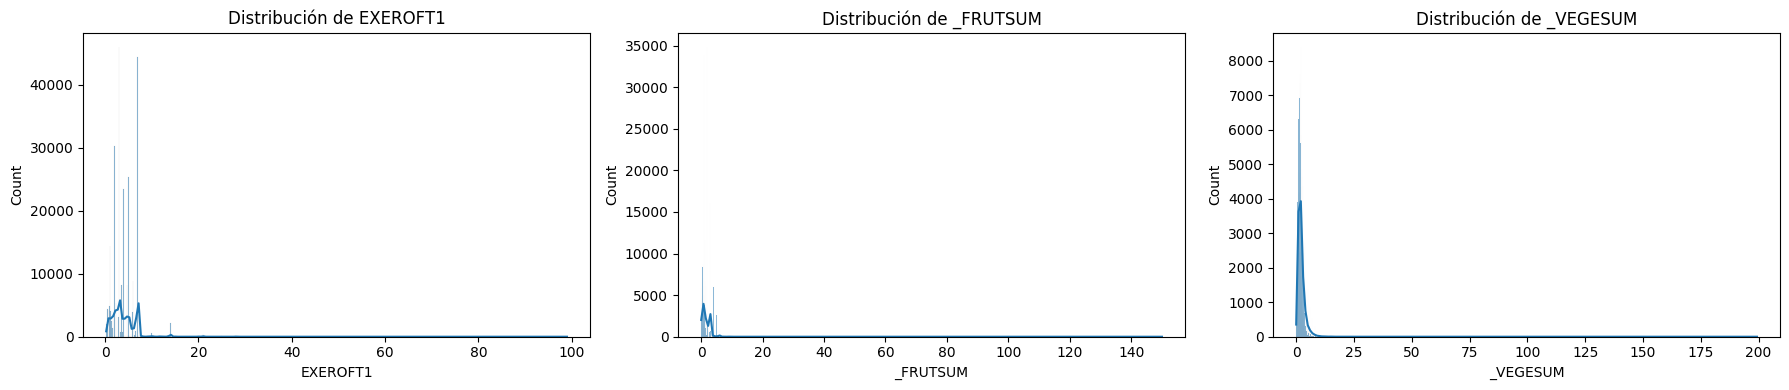

In [ ]:
# Visualizacion de histogramas de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(NUMERIC_VARS):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1285136469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="coolwarm")
/tmp/ipython-input-1285136469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="coolwarm")
/tmp/ipython-input-1285136469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="coolwarm")


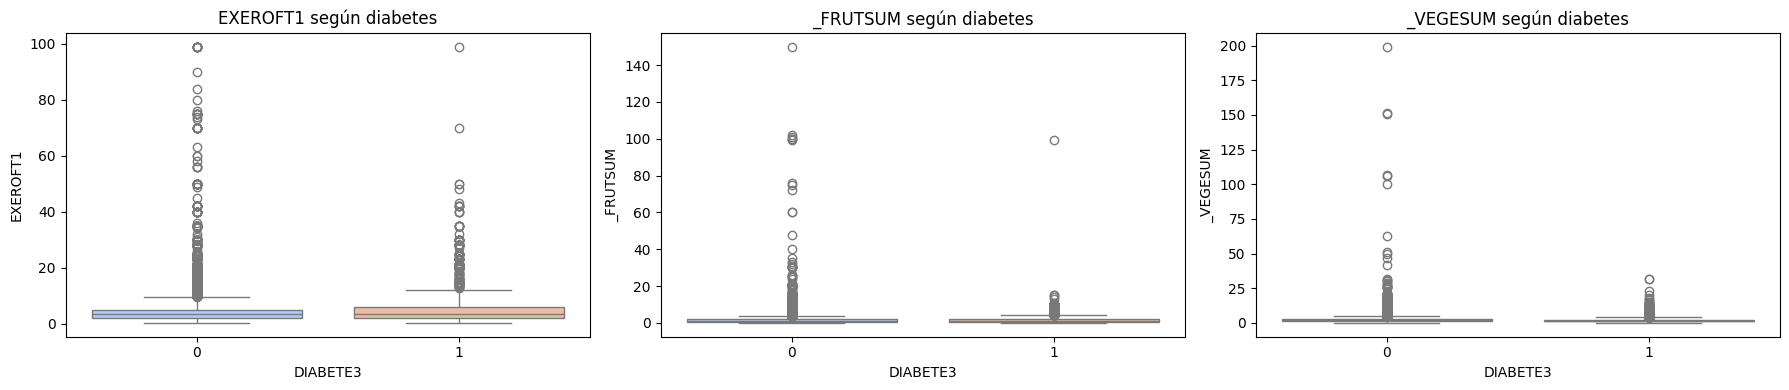

In [ ]:
# Visualización boxplots por estado de diabetes
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(NUMERIC_VARS):
    sns.boxplot(x=TARGET, y=col, data=df, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"{col} según diabetes")
plt.tight_layout()
plt.show()

In [ ]:
def boxplot_stats(df_input, column):
    """
    Calcula límites inferior y superior para detectar outliers
    usando el método de boxplot (1.5 * IQR).

    Args:
        df_input (pd.DataFrame): Dataset de entrada.
        column (str): Columna numérica a evaluar.

    Returns:
        dict: Límites {'lower_fence': valor_min, 'upper_fence': valor_max}.
    """
    s = df_input[column].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return {"lower_fence": q1 - 1.5 * iqr, "upper_fence": q3 + 1.5 * iqr}

In [ ]:
# Llímites de cada variable numérica
print(boxplot_stats(df, 'EXEROFT1'))
print(boxplot_stats(df, '_FRUTSUM'))
print(boxplot_stats(df, '_VEGESUM'))

{'lower_fence': -2.5, 'upper_fence': 9.5}
{'lower_fence': -1.3250000000000002, 'upper_fence': 3.995}
{'lower_fence': -0.8549999999999998, 'upper_fence': 4.625}


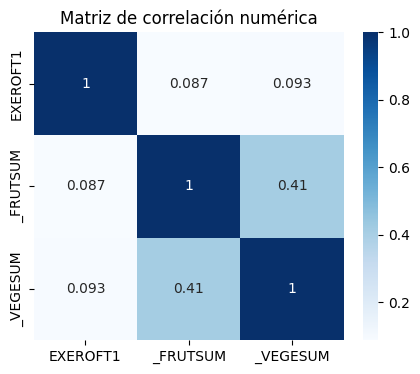

In [ ]:
# Matriz de correlación entre variables numéricas
corr = df[NUMERIC_VARS].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Matriz de correlación numérica")
plt.show()

### 3.5. Correlaciones combinadas (numéricas + ordinales + target)

In [ ]:
def eda_correlations(df_input, numeric_vars, categorical_ordinal, target):
    """
    Calcula y visualiza la matriz de correlaciones entre variables
    numéricas, ordinales y el target.

    Args:
        df_input (pd.DataFrame): Dataset de entrada.
        numeric_vars (list): Lista de variables numéricas.
        categorical_ordinal (list): Lista de variables ordinales.
        target (str): Nombre de la variable objetivo.
    """
    print("\n=========== MATRIZ DE CORRELACIONES ===========\n")

    corr_vars = numeric_vars + categorical_ordinal
    corr_df = df_input[corr_vars].copy()
    corr_df[target] = df_input[target]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlaciones numéricas + ordinales + target")
    plt.tight_layout()
    plt.show()


=========== MATRIZ DE CORRELACIONES ===========



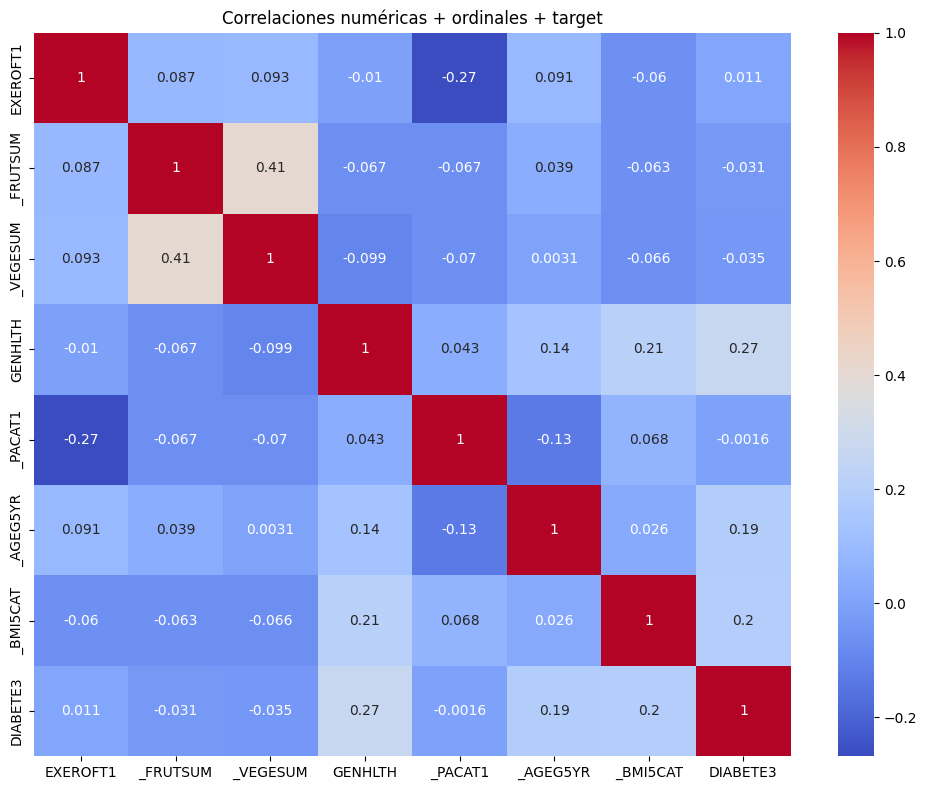

In [ ]:
eda_correlations(df, NUMERIC_VARS, CATEGORICAL_ORDINAL, TARGET)

## 4. División del dataset

In [ ]:
# pylint: disable=C0103
# pylint: disable=W0621
# Las variables de entrenamiento/validación/test usan nombres clásicos de ML:
# X_train, y_train, X_val, X_test, etc.

# Separación de features y target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# División: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (154625, 22), Val: (51542, 22), Test: (51542, 22)


## 5. Pipelines de preprocesamiento

### 5.1. Separación por tipo de variable

In [ ]:
# Variables nominales con varias categorías (para OneHot en RF)
CATEGORICAL_NOMINAL_MODEL = ['BPHIGH4', '_RACE']

# Variables binarias (imputación 0/1 en determinista)
BINARY_VARS = ['BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2',
               'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK',
               'DIFFALON', 'DIFFDRES', 'SMOKE100', 'ADDEPEV2', 'SEX']

# Variables ordinales
CATEGORICAL_ORDINAL_MODEL = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']

# Variables numéricas
NUMERIC_VARS_MODEL = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']

### 5.2. Preprocesamiento determinista

In [ ]:
def deterministic_preproc(X):
    """
    - Sustituye los valores codificados como -1 por NaN.
    - Convierte las variables binarias a formato 0/1,
      asignando 0 a los valores distintos de 1.
    """
    X = X.copy()

    # Reemplazo global de valores -1 por NaN
    X = X.replace(-1, np.nan)

    # Normalización de variables binarias
    for col in BINARY_VARS:
        X[col] = (X[col] == 1).astype(int)

    return X

### 5.3. Transformadores por tipo de variable

In [ ]:
# Nominal: Most frequent y OneHot
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ordinal: Most frequent
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Numéricas: KNN Imputer y StandardScaler
numeric_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

### 5.4 ColumnTransformers

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline, CATEGORICAL_NOMINAL_MODEL),
    ('bin', 'passthrough', BINARY_VARS),  # Ya procesado en determinista
    ('ord', ordinal_pipeline, CATEGORICAL_ORDINAL_MODEL),
    ('num', numeric_pipeline, NUMERIC_VARS_MODEL),
])

## 6. Definición de modelos

### 6.1. Modelos individuales

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear',
    class_weight='balanced',
    random_state=42
    )

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=350,
    class_weight='balanced',
    random_state=42
    )

# Gaussian Naive Bayes
gnb_model = GaussianNB()

### 6.2. Pipelines finales por modelo

In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('deterministic', FunctionTransformer(deterministic_preproc)),
        ('preprocessor', preprocessor),
        ('model', lr_model)
    ]),
    'Decision Tree Classifier': Pipeline([
        ('deterministic', FunctionTransformer(deterministic_preproc)),
        ('preprocessor', preprocessor),
        ('model', dt_model)
    ]),
    'Gaussian Naive Bayes': Pipeline([
        ('deterministic', FunctionTransformer(deterministic_preproc)),
        ('preprocessor', preprocessor),
        ('model', GaussianNB())
    ])
}

## 7. Entrenamiento y evaluación

### 7.1. Preparación de conjuntos de validación y test

In [ ]:
# Umbral por defecto
threshold = 0.5

# Asegura que X_val y X_test sean DataFrames con mismos nombres y orden de columnas que X_train
X_val = pd.DataFrame(X_val, columns=X_train.columns)
X_test = pd.DataFrame(X_test, columns=X_train.columns)

# Diccionarios para almacenar predicciones y probabilidades
y_prob_val_dict = {}
y_prob_test_dict = {}

# Listas para resultados de métricas
results_val = []
results_test = []

### 7.2. Entrenamiento de modelos y cálculo de métricas (Val/Test)

In [ ]:
for model_name, pipeline in models.items():
    # Entrenamiento
    pipeline.fit(X_train, y_train)

    # Predicciones probabilísticas
    y_prob_val = pipeline.predict_proba(X_val)[:, 1]
    y_prob_test = pipeline.predict_proba(X_test)[:, 1]

    # Almacenamiento para reutilización
    y_prob_val_dict[model_name] = y_prob_val
    y_prob_test_dict[model_name] = y_prob_test

    # Curvas Precision-Recall
    precision_val, recall_val, _ = precision_recall_curve(y_val, y_prob_val)
    precision_test, recall_test, _ = precision_recall_curve(y_test, y_prob_test)

    # Métricas ROC-AUC y PR-AUC
    results_val.append({
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_val, y_prob_val),
        'PR-AUC': auc(recall_val, precision_val)
    })
    results_test.append({
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_test, y_prob_test),
        'PR-AUC': auc(recall_test, precision_test)
    })

# Resultados en DataFrame
df_val_results = pd.DataFrame(results_val)
df_test_results = pd.DataFrame(results_test)

print("=== Métricas (Validación) ===")
display(df_val_results)

print("=== Métricas (Test) ===")
display(df_test_results)

=== Métricas (Validación) ===


,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.838417,0.369358
1,Decision Tree Classifier,0.822765,0.360533
2,Gaussian Naive Bayes,0.787735,0.292794


=== Métricas (Test) ===


,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.834502,0.370345
1,Decision Tree Classifier,0.818754,0.356061
2,Gaussian Naive Bayes,0.786834,0.292283


### 7.3. Curvas ROC (Discriminación global del modelo)

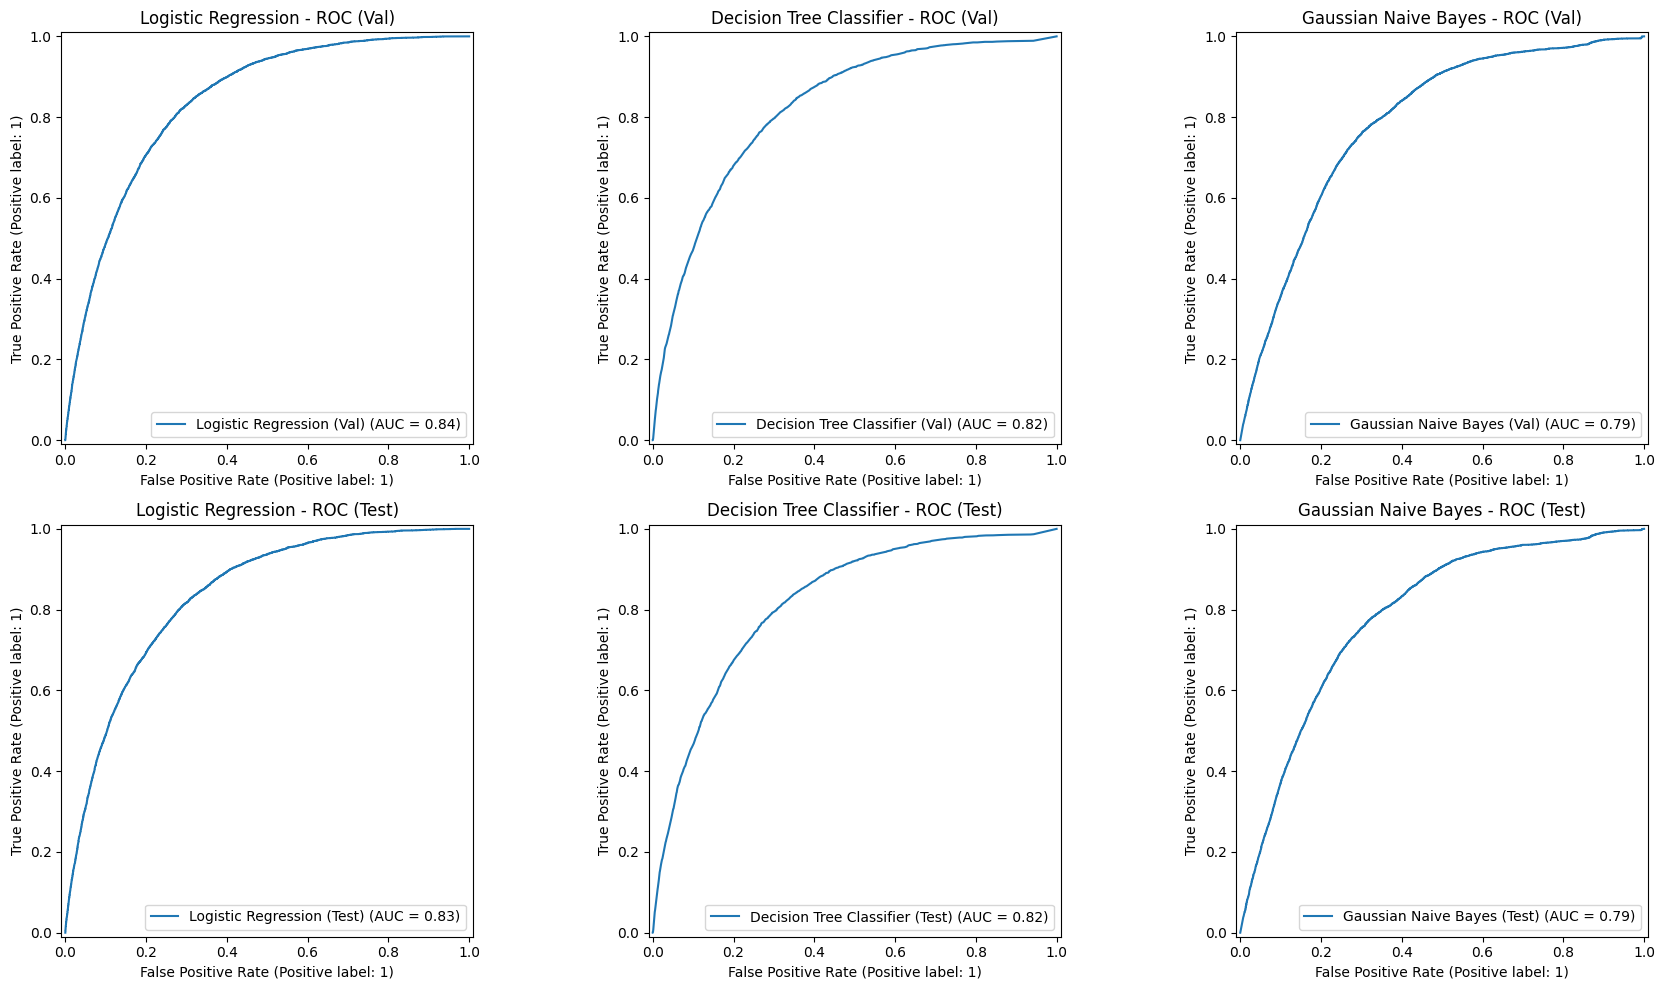

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, model_name in enumerate(models):
    # Validación
    RocCurveDisplay.from_predictions(
        y_val, y_prob_val_dict[model_name],
        name=f"{model_name} (Val)", ax=axes[0, idx]
    )
    axes[0, idx].set_title(f'{model_name} - ROC (Val)')

    # Test
    RocCurveDisplay.from_predictions(
        y_test, y_prob_test_dict[model_name],
        name=f"{model_name} (Test)", ax=axes[1, idx]
    )
    axes[1, idx].set_title(f'{model_name} - ROC (Test)')

plt.tight_layout()
plt.show()

### 7.4. Curvas Precision–Recall

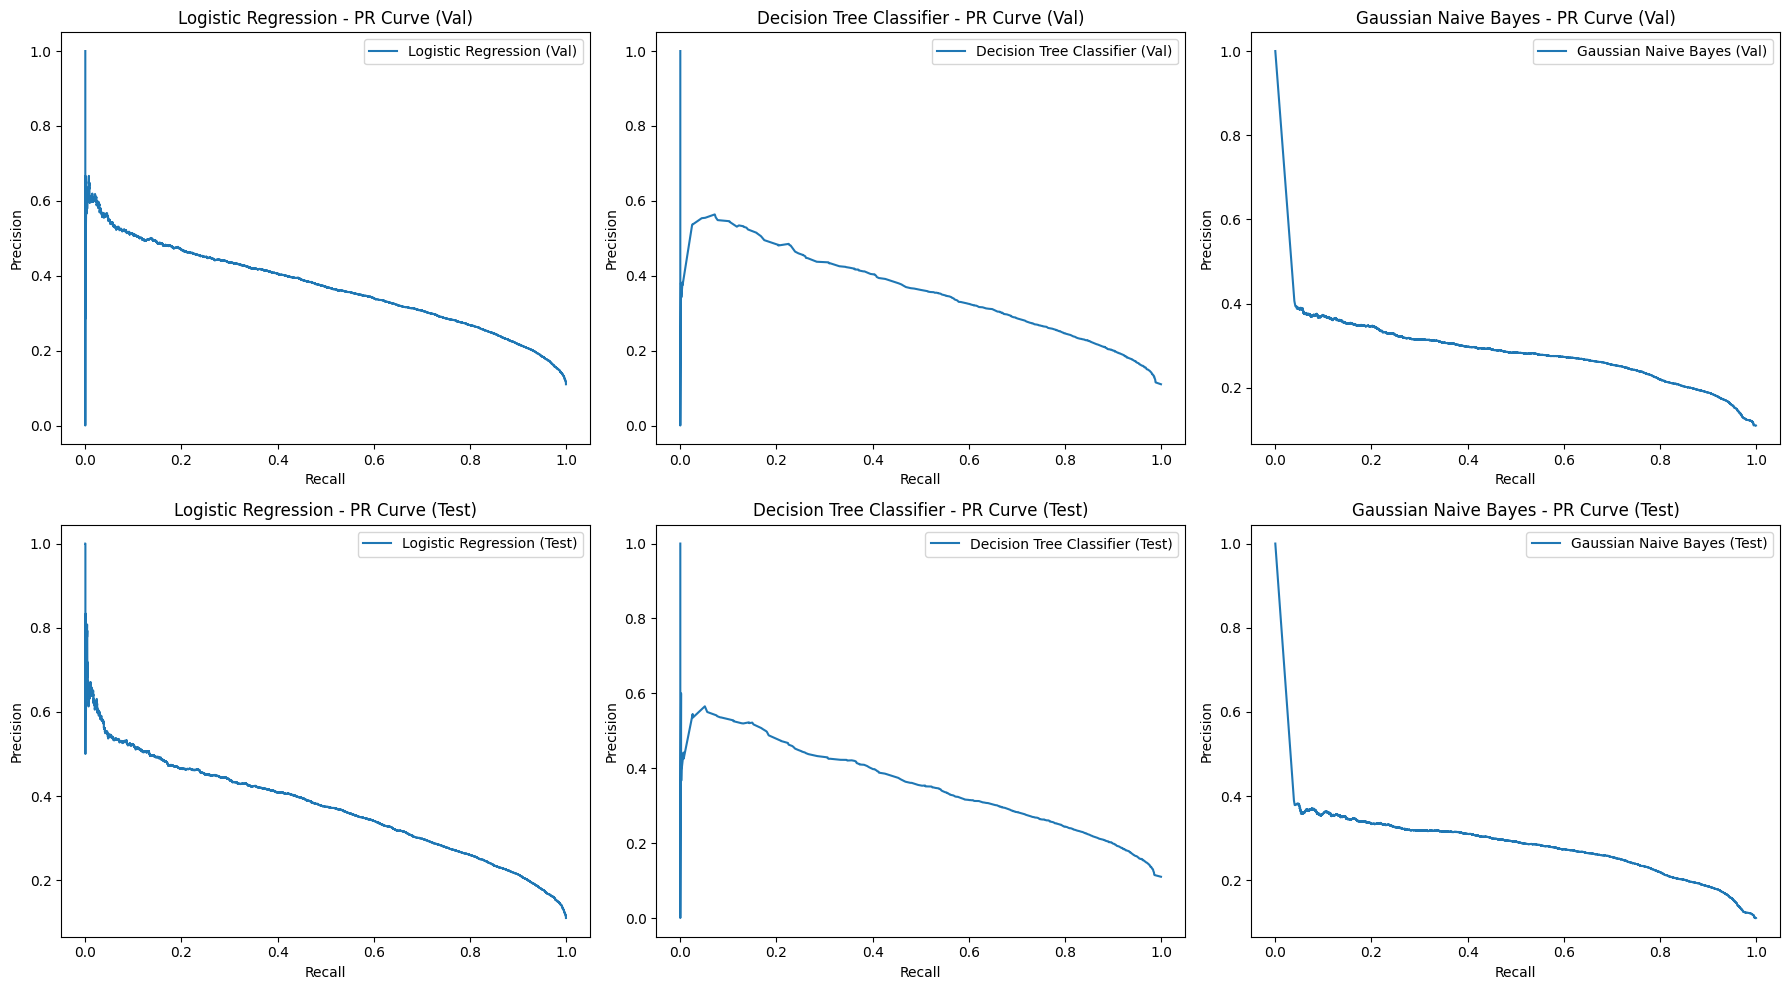

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, model_name in enumerate(models):
    # Validación
    precision_val, recall_val, _ = precision_recall_curve(
        y_val, y_prob_val_dict[model_name]
    )
    axes[0, idx].plot(recall_val, precision_val, label=f'{model_name} (Val)')
    axes[0, idx].set_xlabel('Recall')
    axes[0, idx].set_ylabel('Precision')
    axes[0, idx].set_title(f'{model_name} - PR Curve (Val)')
    axes[0, idx].legend()

    # Test
    precision_test, recall_test, _ = precision_recall_curve(
        y_test, y_prob_test_dict[model_name]
    )
    axes[1, idx].plot(recall_test, precision_test, label=f'{model_name} (Test)')
    axes[1, idx].set_xlabel('Recall')
    axes[1, idx].set_ylabel('Precision')
    axes[1, idx].set_title(f'{model_name} - PR Curve (Test)')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

### 7.5. Matrices de confusión

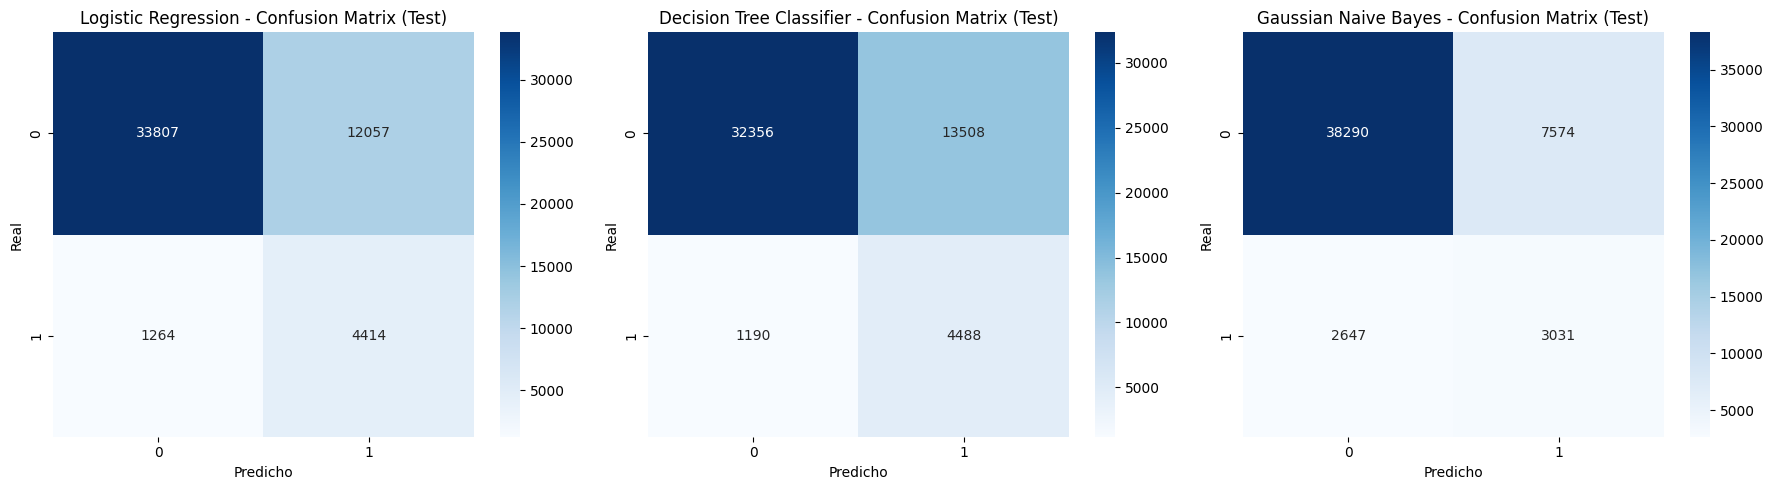

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(models):
    y_pred_test = (y_prob_test_dict[model_name] >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_test)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{model_name} - Confusion Matrix (Test)')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

### 7.4 Resultados finales

In [ ]:
final_results = []

for name in models:
    y_pred_test = (y_prob_test_dict[name] >= threshold).astype(int)

    precision, recall, _ = precision_recall_curve(
        y_test, y_prob_test_dict[name]
    )

    final_results.append({
        'Model': name,
        'Threshold': threshold,
        'Recall': recall_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'F1-score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test_dict[name]),
        'PR-AUC': auc(recall, precision)
    })

df_final_results = pd.DataFrame(final_results)
display(df_final_results)

,Model,Threshold,Recall,Precision,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.5,0.777386,0.267986,0.398573,0.834502,0.370345
1,Decision Tree Classifier,0.5,0.790419,0.249389,0.379150,0.818754,0.356061
2,Gaussian Naive Bayes,0.5,0.533815,0.285809,0.372290,0.786834,0.292283
